In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

# find the actual input path
'''for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        print(os.path.join(root, f))'''
print ("cell executed")
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

cell executed


 CAFA5 Protein Function Prediction

## Problem
Multi-label classification: predict GO terms for 142k proteins.

## Approach
- Features: Amino acid composition (20) + k-mer bigrams (400) = 420 features
- Model: Logistic Regression with MultiOutputClassifier (1000 GO terms)
- Evaluation: Fmax = 0.34 at threshold 0.25

## Results
- Training set: 113,796 proteins
- Test set: 28,450 proteins  
- Fmax: 0.3372
- Submission: 495,294 predictions above threshold

## Next Steps
- ESM-2 embeddings for richer features
- XGBoost model comparison

In [2]:
#This block defines file paths for the CAFA-5 dataset so I can load the data later without repeatedly typing long strings.


BASE = "/kaggle/input/competitions/cafa-5-protein-function-prediction"

FASTA_PATH = f"{BASE}/Train/train_sequences.fasta"
TERMS_PATH = f"{BASE}/Train/train_terms.tsv"
TAXON_PATH = f"{BASE}/Train/train_taxonomy.tsv"
TEST_PATH  = f"{BASE}/Test (Targets)/testsuperset.fasta"
print ("cell executed")

cell executed


In [3]:
!pip install biopython -q
print ("cell executed")

cell executed


In [4]:
from Bio import SeqIO
import pandas as pd

# load sequences
def load_fasta(path):
    records = []
    for rec in SeqIO.parse(path, "fasta"):
        records.append({
            "protein_id": rec.id,
            "sequence":   str(rec.seq),
            "seq_len":    len(rec.seq)
        })
    return pd.DataFrame(records)

df_seqs  = load_fasta(FASTA_PATH)
print ("cell executed")

cell executed


In [5]:
df_terms = pd.read_csv(
    TERMS_PATH, 
    sep="\t",
    names=["protein_id", "go_id", "ontology"])

In [6]:

print("Sequences:", df_seqs.shape)
print("Labels:   ", df_terms.shape)
print()
print(df_seqs.head(3))
print()
print(df_terms.head(3))

Sequences: (142246, 3)
Labels:    (5363864, 3)

  protein_id                                           sequence  seq_len
0     P20536  MNSVTVSHAPYTITYHDDWEPVMSQLVEFYNEVASWLLRDETSPIP...      218
1     O73864  MTEYRNFLLLFITSLSVIYPCTGISWLGLTINGSSVGWNQTHHCKL...      354
2     O95231  MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...      258

   protein_id       go_id ontology
0     EntryID        term   aspect
1  A0A009IHW8  GO:0008152      BPO
2  A0A009IHW8  GO:0034655      BPO


In [7]:
# drop the false header row that snuck in as data
df_terms = df_terms[df_terms["protein_id"] != "EntryID"].reset_index(drop=True)

print("Labels after fix:", df_terms.shape)
print(df_terms.head(3))
print()
print("Ontology counts:")
print(df_terms["ontology"].value_counts())

Labels after fix: (5363863, 3)
   protein_id       go_id ontology
0  A0A009IHW8  GO:0008152      BPO
1  A0A009IHW8  GO:0034655      BPO
2  A0A009IHW8  GO:0072523      BPO

Ontology counts:
ontology
BPO    3497732
CCO    1196017
MFO     670114
Name: count, dtype: int64


In [8]:
# labels per protein
labels_per_protein = df_terms.groupby("protein_id")["go_id"].count()
print("Labels per protein:")
print(labels_per_protein.describe().round(1))

Labels per protein:
count    142246.0
mean         37.7
std          42.5
min           2.0
25%          10.0
50%          24.0
75%          50.0
max         815.0
Name: go_id, dtype: float64


In [9]:
# top 10 most common GO terms
print("\nTop 10 GO terms:")
print(df_terms["go_id"].value_counts().head(10))


Top 10 GO terms:
go_id
GO:0005575    92912
GO:0008150    92210
GO:0110165    91286
GO:0003674    78637
GO:0005622    70785
GO:0009987    61293
GO:0043226    60883
GO:0043229    58315
GO:0005488    57380
GO:0043227    55452
Name: count, dtype: int64


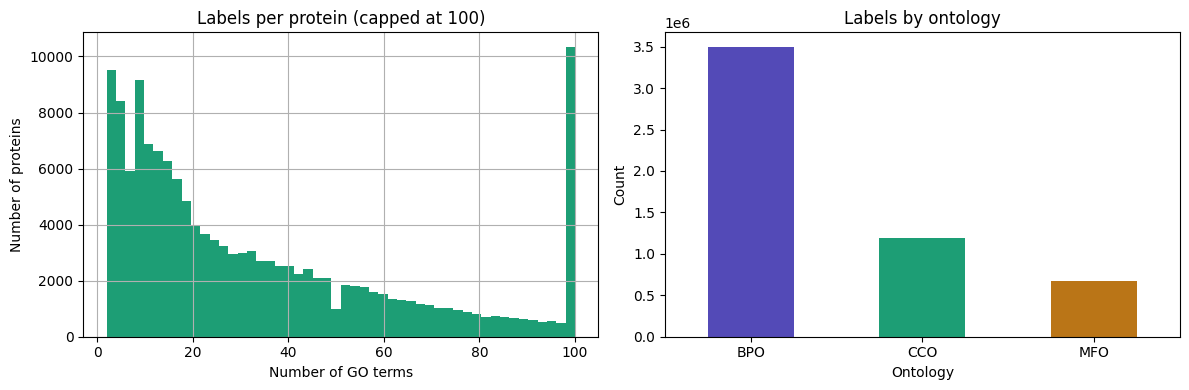

In [10]:
import matplotlib.pyplot as plt
# plot distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels_per_protein.clip(upper=100).hist(bins=50, ax=axes[0], color="#1D9E75")
axes[0].set_title("Labels per protein (capped at 100)")
axes[0].set_xlabel("Number of GO terms")
axes[0].set_ylabel("Number of proteins")

df_terms["ontology"].value_counts().plot(kind="bar", ax=axes[1], color=["#534AB7","#1D9E75","#BA7517"])
axes[1].set_title("Labels by ontology")
axes[1].set_xlabel("Ontology")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [11]:
# merge sequences + labels
labels_grouped = (df_terms.groupby("protein_id")["go_id"]
                           .apply(list)
                           .reset_index()
                           .rename(columns={"go_id": "go_terms"}))

df_train = df_seqs.merge(labels_grouped, on="protein_id", how="inner")
print("Training set shape:", df_train.shape)
print(df_train.head(2))

Training set shape: (142246, 4)
  protein_id                                           sequence  seq_len  \
0     P20536  MNSVTVSHAPYTITYHDDWEPVMSQLVEFYNEVASWLLRDETSPIP...      218   
1     O73864  MTEYRNFLLLFITSLSVIYPCTGISWLGLTINGSSVGWNQTHHCKL...      354   

                                            go_terms  
0  [GO:0008152, GO:0071897, GO:0044249, GO:000625...  
1  [GO:0061371, GO:0048589, GO:0051641, GO:004885...  


In [12]:
# keeping only top 1000 most frequent GO terms
# (the rest appear too rarely to learn from in a baseline)
TOP_N = 1000
top_terms = df_terms["go_id"].value_counts().head(TOP_N).index.tolist()
print(f"Keeping {len(top_terms)} GO terms")
print(f"These cover {df_terms['go_id'].isin(top_terms).mean()*100:.1f}% of all label rows")

Keeping 1000 GO terms
These cover 77.3% of all label rows


In [13]:
labels_grouped = (df_terms[df_terms["go_id"].isin(top_terms)]
                           .groupby("protein_id")["go_id"]
                           .apply(list)
                           .reset_index()
                           .rename(columns={"go_id": "go_terms"}))

df_train = df_seqs.merge(labels_grouped, on="protein_id", how="inner")
print("df_train shape:", df_train.shape)
print(df_train.head(2))

df_train shape: (142246, 4)
  protein_id                                           sequence  seq_len  \
0     P20536  MNSVTVSHAPYTITYHDDWEPVMSQLVEFYNEVASWLLRDETSPIP...      218   
1     O73864  MTEYRNFLLLFITSLSVIYPCTGISWLGLTINGSSVGWNQTHHCKL...      354   

                                            go_terms  
0  [GO:0008152, GO:0044249, GO:0006259, GO:000905...  
1  [GO:0048589, GO:0051641, GO:0048856, GO:000996...  


In [14]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer(classes=top_terms)
Y = mlb.fit_transform(df_train["go_terms"])

print("Y shape:", Y.shape)
print("Label density:", round(Y.mean(), 4))

Y shape: (142246, 1000)
Label density: 0.0291


In [15]:
print("Proteins in df_train:", len(df_train))
print("GO terms in Y:", Y.shape[1])
print("Total 1s in Y:", Y.sum())
print("Avg labels per protein:", round(Y.sum(axis=1).mean(), 1))

Proteins in df_train: 142246
GO terms in Y: 1000
Total 1s in Y: 4145527
Avg labels per protein: 29.1


#------------------- feature engineering----------------------

In [16]:
import numpy as np

AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")

def aa_composition(sequence):
    seq = sequence.upper()
    length = len(seq)
    return [seq.count(aa) / length for aa in AMINO_ACIDS]

X_comp = np.array([aa_composition(seq) for seq in df_train["sequence"]])
print("X_comp shape:", X_comp.shape)  # expect (142246, 20)

X_comp shape: (142246, 20)


#------------------------model------------------

In [17]:
from itertools import product
import numpy as np

AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")
KMER_VOCAB = ["".join(p) for p in product(AMINO_ACIDS, repeat=2)]
KMER_INDEX = {km: i for i, km in enumerate(KMER_VOCAB)}

def kmer_frequency_fast(sequence, k=2):
    seq = sequence.upper()
    counts = np.zeros(400)
    for i in range(len(seq) - k + 1):
        kmer = seq[i:i+k]
        idx = KMER_INDEX.get(kmer)
        if idx is not None:
            counts[idx] += 1
    total = counts.sum()
    return counts / total if total > 0 else counts

X_kmer = np.array([kmer_frequency_fast(seq) for seq in df_train["sequence"]])
print("X_kmer shape:", X_kmer.shape)

X_kmer shape: (142246, 400)


In [21]:
X = np.hstack([X_comp, X_kmer])
print("X shape:", X.shape)

X shape: (142246, 420)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)

X_train: (113796, 420)
Y_train: (113796, 1000)


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier

print("Training...")

clf = MultiOutputClassifier(
    LogisticRegression(
        max_iter=1000,
        n_jobs=-1,
        random_state=42
    ),
    n_jobs=-1
)

clf.fit(X_train, Y_train)
print("Training done.")
joblib.dump(clf, 'model.joblib')
print("Model saved!")


Training...
Training done.


NameError: name 'joblib' is not defined

In [25]:
import joblib
joblib.dump(clf, 'model.joblib')
print("Model saved!")


Model saved!


In [26]:
print("Predicting...")
Y_pred_proba = clf.predict_proba(X_test)
print("Done.")
print("Number of output arrays:", len(Y_pred_proba))
print("Shape of first array:", Y_pred_proba[0].shape)

Predicting...
Done.
Number of output arrays: 1000
Shape of first array: (28450, 2)


In [29]:
import numpy as np

# extract just the positive class probability for each GO term
Y_pred = np.column_stack([Y_pred_proba[i][:, 1] for i in range(1000)])

print("Y_pred shape:", Y_pred.shape)  # expect (28450, 1000)
print("Sample predictions (first protein, first 10 terms):")
print(Y_pred[0, :10].round(3))

Y_pred shape: (28450, 1000)
Sample predictions (first protein, first 10 terms):
[0.675 0.599 0.667 0.615 0.615 0.423 0.506 0.479 0.617 0.453]


In [30]:
def compute_fmax(Y_true, Y_pred_proba):
    thresholds = np.arange(0.1, 0.9, 0.05)
    best_f1 = 0
    best_threshold = 0
    
    print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
    print("-" * 48)
    
    for t in thresholds:
        Y_pred_binary = (Y_pred_proba >= t).astype(int)
        
        tp = (Y_pred_binary * Y_true).sum(axis=1)
        pred_pos = Y_pred_binary.sum(axis=1)
        actual_pos = Y_true.sum(axis=1)
        
        precision = np.where(pred_pos > 0, tp / pred_pos, 0)
        recall = np.where(actual_pos > 0, tp / actual_pos, 0)
        
        f1 = np.where(
            (precision + recall) > 0,
            2 * precision * recall / (precision + recall),
            0
        )
        
        mean_precision = precision.mean()
        mean_recall = recall.mean()
        mean_f1 = f1.mean()
        
        print(f"{t:<12.1f} {mean_precision:<12.4f} {mean_recall:<12.4f} {mean_f1:<12.4f}")
        
        if mean_f1 > best_f1:
            best_f1 = mean_f1
            best_threshold = t
    
    return best_f1, best_threshold

fmax, best_t = compute_fmax(Y_test, Y_pred)
print(f"\nFmax:           {fmax:.4f}")
print(f"Best threshold: {best_t:.2f}")

Threshold    Precision    Recall       F1          
------------------------------------------------
0.1          0.2496       0.5794       0.2919      
0.2          0.3310       0.4997       0.3238      
0.2          0.3931       0.4457       0.3358      
0.3          0.4414       0.4023       0.3372      
0.3          0.4742       0.3674       0.3325      


/tmp/ipykernel_110/2239203791.py:21: RuntimeWarning: invalid value encountered in divide
  2 * precision * recall / (precision + recall),


0.4          0.5067       0.3282       0.3209      
0.4          0.5441       0.2791       0.2979      
0.5          0.5817       0.2299       0.2682      
0.5          0.6091       0.1931       0.2423      
0.6          0.6325       0.1582       0.2132      


/tmp/ipykernel_110/2239203791.py:16: RuntimeWarning: invalid value encountered in divide
  precision = np.where(pred_pos > 0, tp / pred_pos, 0)


0.6          0.6560       0.1147       0.1694      
0.7          0.5859       0.0667       0.1057      
0.7          0.2277       0.0222       0.0357      
0.8          0.0480       0.0054       0.0084      
0.8          0.0106       0.0015       0.0023      
0.9          0.0022       0.0004       0.0006      

Fmax:           0.3372
Best threshold: 0.25


In [ ]:
# format predictions into CAFA submission format
def make_submission(protein_ids, Y_pred_proba, go_terms, threshold=0.25):
    rows = []
    for i, protein_id in enumerate(protein_ids):
        for j, go_term in enumerate(go_terms):
            score = Y_pred_proba[i, j]
            if score >= threshold:
                rows.append({
                    "protein_id": protein_id,
                    "go_id": go_term,
                    "score": round(score, 3)
                })
    return pd.DataFrame(rows)

test_protein_ids = df_train["protein_id"].iloc[
    df_train.index.isin(
        df_train.index[int(len(df_train)*0.8):]
    )
].values

submission = make_submission(
    df_train["protein_id"].tail(28450).values,
    Y_pred,
    top_terms,
    threshold=0.25
)

print("Submission shape:", submission.shape)
print(submission.head(10))

In [ ]:
submission.to_csv("submission.csv", index=False)
print("Saved.")

loading esm2

In [1]:
!pip install transformers torch -q

In [2]:
import torch
import transformers

print("PyTorch version:", torch.__version__)
print("Transformers version:", transformers.__version__)
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

PyTorch version: 2.10.0+cu128
Transformers version: 5.0.0
GPU available: True
GPU name: Tesla T4


Imports + paths

In [10]:
import os
import glob
import numpy as np
import torch
from tqdm import tqdm

SAVE_DIR = "/kaggle/working/esm_batches"
os.makedirs(SAVE_DIR, exist_ok=True)

Cell 2 — Device + model

In [11]:
from transformers import AutoTokenizer, AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t33_650M_UR50D")
model = AutoModel.from_pretrained("facebook/esm2_t33_650M_UR50D")
model = model.to(device)
model.eval()
print("Model loaded")

Using device: cuda


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded


Cell 3 — Batched embedding function

In [12]:
def get_esm_embeddings_batch(sequences, tokenizer, model, device):
    inputs = tokenizer(
        sequences,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=1024
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    last_hidden = outputs.last_hidden_state
    mask = inputs["attention_mask"].unsqueeze(-1)

    summed = (last_hidden * mask).sum(dim=1)
    counts = mask.sum(dim=1)

    embeddings = summed / counts
    return embeddings.cpu().numpy()

Cell 4 — Resume logic

In [13]:
import glob
import os
import numpy as np

batch_size = 64
existing_files = sorted(glob.glob(f"{SAVE_DIR}/batch_*.npy"))
done_indices = set()
for f in existing_files:
    idx = int(os.path.basename(f).split("_")[1].split(".")[0])
    done_indices.add(idx)
print("Already completed batches:", len(done_indices))

Already completed batches: 0


Cell 5 — Main loop (safe + resumable)

In [ ]:
# sort by length so similar length proteins batch together
df_train_sorted = df_train.sort_values("seq_len").reset_index(drop=True)

print(f"Total proteins: {len(df_train_sorted)}")

for i in tqdm(range(0, len(df_train_sorted), batch_size)):
    
    if i in done_indices:
        continue

    batch_seqs = df_train_sorted["sequence"].iloc[i:i+batch_size].tolist()
    
    try:
        batch_embs = get_esm_embeddings_batch(
            batch_seqs, tokenizer, model, device
        )
        np.save(f"{SAVE_DIR}/batch_{i}.npy", batch_embs)
        
    except Exception as e:
        print(f"Error at batch {i}: {e}")
        continue

In [ ]:

import torch
print("GPU memory allocated:", torch.cuda.memory_allocated() / 1e9, "GB")
print("GPU memory reserved:", torch.cuda.memory_reserved() / 1e9, "GB")

In [ ]:
import torch

# simple GPU test
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0))

# test one short sequence
test_seq = "MKTAYIAK"
inputs = tokenizer(test_seq, return_tensors="pt", truncation=True, max_length=1024)
inputs = {k: v.to("cuda") for k, v in inputs.items()}

import time
start = time.time()
with torch.no_grad():
    outputs = model(**inputs)
end = time.time()

print(f"One short sequence took: {end-start:.2f} seconds")

In [ ]:
print("Sequence length stats:")
print(df_train["seq_len"].describe())
print("\nProteins over 1024:", (df_train["seq_len"] > 1024).sum())
print("Percentage:", (df_train["seq_len"] > 1024).mean() * 100, "%")

In [ ]:
# Sort by sequence length for efficient batching
df_train_sorted = df_train.sort_values("seq_len").reset_index(drop=True)

print("Proteins over 512:", (df_train_sorted["seq_len"] > 512).sum())
print("Percentage over 512:", round((df_train_sorted["seq_len"] > 512).mean() * 100, 1), "%")

In [ ]:
import subprocess
result = subprocess.run(['find', '/kaggle', '-name', 'batch_*.npy'], capture_output=True, text=True)
print(result.stdout)
print("---")
print(result.stderr)

In [ ]:
import os

BASE = "/kaggle/input/datasets/keerthik22/cafa-5-embedded-files-output-ver-sion-8"

EMB_DIR = f"{BASE}/esm_batches"

In [ ]:
import glob
import numpy as np

files = sorted(glob.glob(f"{EMB_DIR}/*.npy"))

print("num files:", len(files))

X_esm = np.vstack([np.load(f) for f in files])

print("shape:", X_esm.shape)

In [ ]:
print(Y.shape)
print(Y.sum(axis=0)[:10])  # label frequency check

## MLP Architecture



### Overview
A two-layer feedforward neural network (MLP) for multi-label protein function prediction.

### Input
- 1280-dimensional ESM-2 protein embeddings
- One vector per protein, 142,246 proteins total

### Architecture
Input (1280) → Linear → ReLU → Linear → Sigmoid → Output (1000)

| Layer | Input | Output | Activation | Purpose |
|-------|-------|--------|------------|---------|
| Linear 1 | 1280 | 512 | ReLU | Learn patterns from embeddings |
| Linear 2 | 512 | 1000 | Sigmoid | Predict probability per GO term |

### Key Decisions
- **ReLU** on hidden layer — adds non-linearity, kills negative values
- **Sigmoid** on output — squeezes each prediction to [0,1] probability
- **No ReLU on output** — need probabilities, not raw values
- **512 hidden units** — compression forces the network to learn meaningful representations

### Output
- 1000 probabilities, one per GO term
- Each value between 0 and 1
- Threshold sweep used at evaluation time (Fmax metric)

### Framework
PyTorch — runs on GPU (Tesla T4, 15.6GB)